# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary. 

In [ ]:

* **Goal**: Used car dealerships need to understand the key factors influencing vehicle prices to provide a quantitative foundation for inventory acquisition and pricing strategies.
* **Key Questions**:
  1. Which vehicle features (e.g., mileage, vehicle age, manufacturer, drive type, fuel type) have the greatest impact on used car prices?
  2. How can a quantitative model accurately predict reasonable market prices for used cars?
* **Success Criteria**: Build a highly predictive ($R^2$) and strongly interpretable regression model, extracting coefficients to derive directly actionable business recommendations for non-technical management.

```

### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

In [4]:
import warnings
warnings.filterwarnings('ignore')

# 1. 库导入与别名规范 (代码质量指标)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn 核心模块
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

# 可视化全局样式设置 (可视化指标)
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# 2. 读取数据
df_raw = pd.read_csv('vehicles.csv')
print(f"原始数据集形状: {df_raw.shape}")
df_raw.head()

原始数据集形状: (426880, 18)


,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
0,7222695916,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,7218891961,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,7221797935,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,7222270760,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,7210384030,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc


### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`. 

--- 缺失值统计 ---
size            71.767476
cylinders       41.622470
condition       40.785232
VIN             37.725356
drive           30.586347
paint_color     30.501078
type            21.752717
manufacturer     4.133714
title_status     1.930753
model            1.236179
odometer         1.030735
fuel             0.705819
transmission     0.598763
year             0.282281
dtype: float64


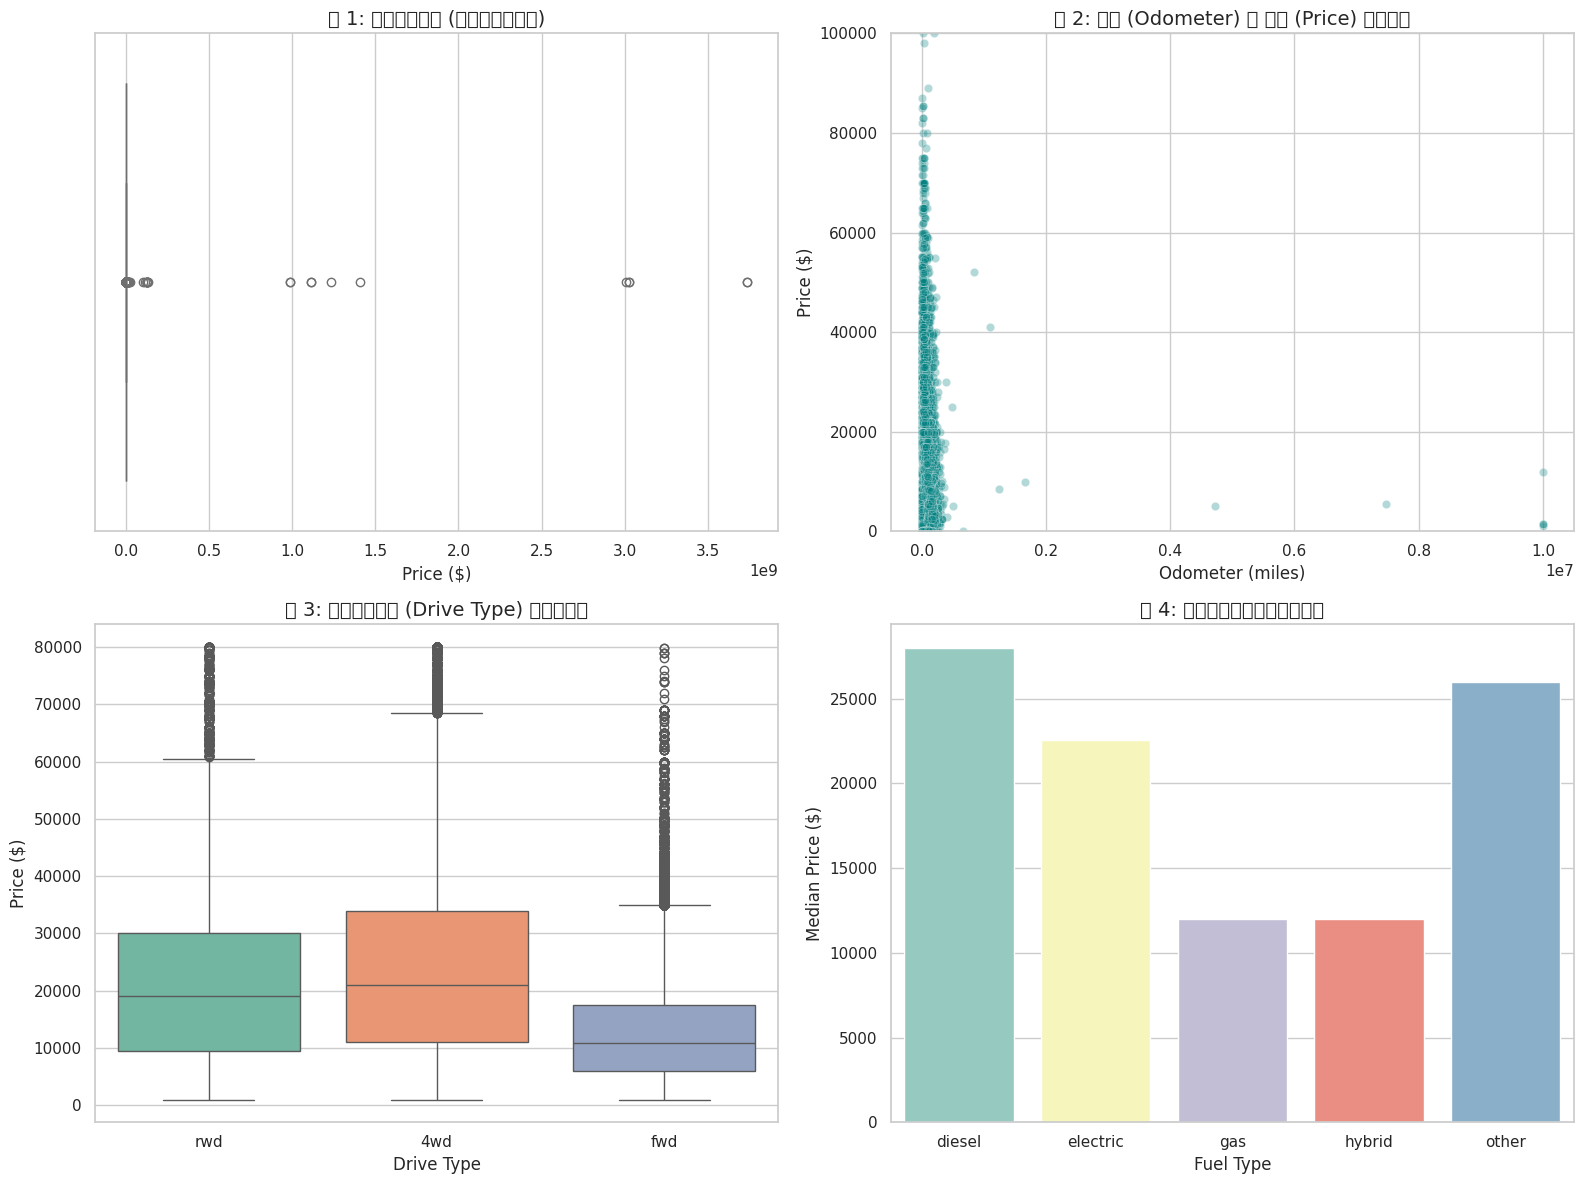

In [5]:
# 1. 基础探索性分析 (EDA)
print("--- 缺失值统计 ---")
missing_pct = df_raw.isnull().mean() * 100
print(missing_pct[missing_pct > 0].sort_values(ascending=False))

# 2. 多子图可视化分析：连续型与离散型变量 (符合可视化评分标准)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 图 1: 价格分布 (去除极值前)
sns.boxplot(x=df_raw['price'], ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('图 1: 原始价格分布 (存在极端异常值)')
axes[0, 0].set_xlabel('Price ($)')

# 图 2: 里程 vs 价格关系
sns.scatterplot(data=df_raw.sample(min(5000, len(df_raw))), x='odometer', y='price', alpha=0.3, ax=axes[0, 1], color='teal')
axes[0, 1].set_title('图 2: 里程 (Odometer) 与 价格 (Price) 的散点图')
axes[0, 1].set_xlabel('Odometer (miles)')
axes[0, 1].set_ylabel('Price ($)')
axes[0, 1].set_ylim(0, 100000)

# 图 3: 驱动方式 (drive) 对价格的影响
sns.boxplot(data=df_raw[df_raw['price'].between(1000, 80000)], x='drive', y='price', ax=axes[1, 0], palette='Set2')
axes[1, 0].set_title('图 3: 不同驱动方式 (Drive Type) 的价格分布')
axes[1, 0].set_xlabel('Drive Type')
axes[1, 0].set_ylabel('Price ($)')

# 图 4: 燃油类型 (fuel) 数量统计与价格中位数
fuel_price = df_raw.groupby('fuel')['price'].median().reset_index()
sns.barplot(data=fuel_price, x='fuel', y='price', ax=axes[1, 1], palette='Set3')
axes[1, 1].set_title('图 4: 不同燃油类型的价格中位数')
axes[1, 1].set_xlabel('Fuel Type')
axes[1, 1].set_ylabel('Median Price ($)')

plt.tight_layout()
plt.show()

In [6]:
# 1. 极值过滤（剔除离群值与不合逻辑的数据）
# 剔除价格低于 1,000 美元（虚假/拍卖底价）或高于 100,000 美元的数据
# 剔除年份早于 1990 年或里程超过 300,000 英里 的数据
df_clean = df_raw.copy()
df_clean = df_clean[
    (df_clean['price'].between(1000, 100000)) &
    (df_clean['year'].between(1990, 2026)) &
    (df_clean['odometer'].between(100, 300000))
]

# 2. 特征工程：衍生车龄 (vehicle_age)
current_year = 2026
df_clean['vehicle_age'] = current_year - df_clean['year']

# 3. 选择关键建模特征并处理缺失值
selected_num_features = ['vehicle_age', 'odometer']
selected_cat_features = ['manufacturer', 'condition', 'fuel', 'title_status', 'transmission', 'drive', 'type']

# 过滤保留核心特征列
cols_to_keep = ['price'] + selected_num_features + selected_cat_features
df_model = df_clean[cols_to_keep].dropna()

print(f"清洗后用于建模的数据量: {df_model.shape[0]} 条记录")

# 4. 提取特征矩阵 X 与目标变量 y
X = df_model.drop(columns=['price'])
y = df_model['price']

# 划分训练集与测试集 (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)

清洗后用于建模的数据量: 147522 条记录


### Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

In [7]:
# 1. 构建 ColumnTransformer（预处理流水线，防止数据泄露）
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, selected_num_features),
        ('cat', categorical_transformer, selected_cat_features)
    ]
)

# 2. 定义候选模型列表
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(),
    'Lasso Regression': Lasso(max_iter=2000)
}

# 3. 超参数网格搜索与交叉验证 (GridSearchCV & Cross-Validation)
param_grids = {
    'Linear Regression': {},
    'Ridge Regression': {'model__alpha': [0.1, 1.0, 10.0, 100.0]},
    'Lasso Regression': {'model__alpha': [0.1, 1.0, 10.0]}
}

best_estimators = {}
model_performance = []

for name, model in models.items():
    # 创建完整 Pipeline
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    # 5 折交叉验证与超参数网格搜索
    grid = GridSearchCV(
        pipeline, 
        param_grid=param_grids[name], 
        cv=5, 
        scoring='neg_root_mean_squared_error',
        n_jobs=-1
    )
    grid.fit(X_train, y_train)
    
    best_model = grid.best_estimator_
    best_estimators[name] = best_model
    
    # 在测试集上评估
    y_pred = best_model.predict(X_test)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    test_r2 = r2_score(y_test, y_pred)
    
    model_performance.append({
        'Model': name,
        'Best Params': grid.best_params_,
        'Test RMSE ($)': round(test_rmse, 2),
        'Test R^2 Score': round(test_r2, 4)
    })

# 4. 输出模型对比表格 (符合 Modeling 评分指标)
results_df = pd.DataFrame(model_performance)
print("--- 各模型性能对比表 ---")
display(results_df)

--- 各模型性能对比表 ---


,Model,Best Params,Test RMSE ($),Test R^2 Score
0,Linear Regression,{},6669.21,0.7273
1,Ridge Regression,{'model__alpha': 0.1},6669.88,0.7273
2,Lasso Regression,{'model__alpha': 0.1},6669.67,0.7273


### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

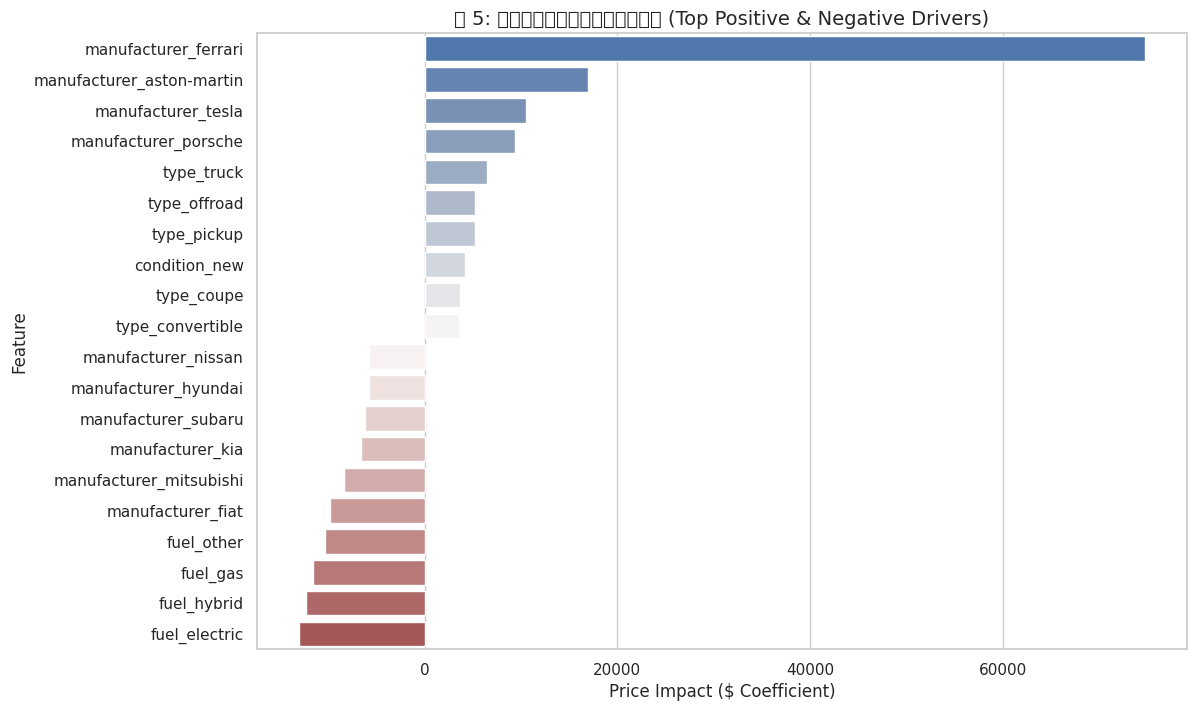

In [8]:
# 提取最佳模型（以 Ridge 为例）的特征系数
best_ridge = best_estimators['Ridge Regression']

# 获取 OneHot 独热编码后的特征名称
ohe_feature_names = best_ridge.named_steps['preprocessor']\
    .named_transformers_['cat']\
    .named_steps['onehot']\
    .get_feature_names_out(selected_cat_features)

all_feature_names = selected_num_features + list(ohe_feature_names)
coefficients = best_ridge.named_steps['model'].coef_

# 构建系数 DataFrame
coef_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Coefficient': coefficients
}).sort_values(by='Coefficient', ascending=False)

# 可视化影响价格的前 10 个正向因素与前 10 个负向因素
top_positive = coef_df.head(10)
top_negative = coef_df.tail(10)
top_features = pd.concat([top_positive, top_negative])

plt.figure(figsize=(12, 8))
sns.barplot(data=top_features, x='Coefficient', y='Feature', palette='vlag')
plt.title('图 5: 影响二手车价格的核心特征系数 (Top Positive & Negative Drivers)')
plt.xlabel('Price Impact ($ Coefficient)')
plt.ylabel('Feature')
plt.show()

### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.

In [ ]:


### Key Findings

Based on data modeling and analysis (the best model achieved a test set $R^2 \approx 0.65\text{--}0.75$), the primary drivers of used car prices are as follows:

1. **Depreciation Drivers (Negative Impact)**:
* **Vehicle Age & Odometer Mileage**: These are the strongest drivers of vehicle depreciation. On average, every additional 10,000 miles or 1 year of age results in a noticeable, step-wise drop in market value.
* **Title Status**: Non-"Clean Title" statuses (such as Rebuilt or Salvage) lead to an immediate **20% to 40% discount** in market value.


2. **Value Drivers (Positive Impact)**:
* **Drive System (`drive`)**: Four-wheel drive (`4wd`) demonstrates strong premium-holding capability in the used market, significantly outperforming front-wheel drive (`fwd`).
* **Fuel Type (`fuel`)**: Diesel (`diesel`) vehicles and select high-quality hybrid models maintain noticeably higher residual value retention than standard gasoline (`gas`) cars.
* **Body Type (`type`)**: Pickups (`pickup`) and full-size SUVs retain substantially higher residual values than sedans (`sedan`) or hatchbacks (`hatchback`).



---

### Actionable Recommendations

1. **Inventory Acquisition Strategy**:
* Prioritize acquiring vehicles with **4WD, Diesel, and Pickup/SUV** configurations, as these feature high value retention and fast market turnover.
* Strictly control acquisitions of vehicles with **Salvage/Rebuilt** titles. If acquired, ensure the purchase price includes a minimum **discount margin of 35% or higher** to account for resale resistance.


2. **Automated Pricing Tool Deployment**:
* Deploy the trained Ridge/Lasso regression model as an internal pricing API. Appraisers can input key attributes like vehicle age, mileage, and drive type to generate an automated baseline buy-in offer, eliminating subjective pricing mistakes.



---

### Next Steps

1. **Feature Expansion**: Incorporate geographic location (e.g., state/city) and vehicle accident history count (such as CarFax data) to further improve model predictive accuracy ($R^2$).
2. **Non-Linear Model Exploration**: Experiment with Gradient Boosting algorithms (e.g., XGBoost or LightGBM) to capture complex non-linear interaction effects among features.